In [14]:
import sys
import os

path_to_scripts = os.path.join('..', '..', 'python_scripts')
sys.path.append(path_to_scripts)

%load_ext autoreload


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb

from google.cloud import storage


from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score, mean_absolute_error, max_error

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

from data_to_bigquery import load_from_bigquery
from feature_engineering import drop_lag_nulls, validate_features, engineer_features
from baseline_model import baseline_model_xgb, xgb_train_preproc, evaluate_trained_model, pred_preproc_xgb, xgb_prediction,baseline_model_xgb_1, baseline_model_xgb_2, gridsearch_model_xgb
from model_saving import save_and_upload_to_gcp, save_and_upload_anything

%matplotlib inline

## Initial laoding and fucntion checking

In [4]:
df = load_from_bigquery('gridzero-489711', 'merged_set', 'test_merge_2017_onward_raw')

/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 148,991 rows and 26 columns from gridzero-489711.merged_set.test_merge_2017_onward_raw


In [6]:
print(df.columns.tolist())
print(df.dtypes)
print(df.head(2))

['datetime', 'temperature_2m_c', 'wind_speed_100m_ms', 'wind_gusts_10m_ms', 'cloud_cover_pct', 'shortwave_radiation_wm2', 'direct_radiation_wm2', 'diffuse_radiation_wm2', 'pressure_msl_hpa', 'snowfall_cm', 'rain_mm', 'precipitation_mm', 'Biomass', 'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil', 'Hydro Pumped Storage', 'Hydro Run-of-river and poundage', 'Nuclear', 'Other', 'Solar', 'Wind Offshore', 'Wind Onshore', 'TotalOutput-MW', 'carbon_intensity_gCO2_kWh', 'status']
datetime                           datetime64[us]
temperature_2m_c                          float64
wind_speed_100m_ms                        float64
wind_gusts_10m_ms                         float64
cloud_cover_pct                             Int64
shortwave_radiation_wm2                   float64
direct_radiation_wm2                      float64
diffuse_radiation_wm2                     float64
pressure_msl_hpa                          float64
snowfall_cm                               float64
rain_mm                   

In [5]:
df.shape

(148991, 26)

Claude suggested feature engineering to improve

In [ ]:
# Run on full df BEFORE your train/test split

# 1. Rolling carbon stats — biggest likely win
df['carbon_rolling_mean_24h'] = df['carbon_intensity_gco2_kwh'].shift(1).rolling(48).mean()
df['carbon_rolling_std_24h']  = df['carbon_intensity_gco2_kwh'].shift(1).rolling(48).std()
df['carbon_rolling_mean_7d']  = df['carbon_intensity_gco2_kwh'].shift(1).rolling(336).mean()

# 2. Renewable vs fossil ratios
df['renewable_ratio'] = (df['wind_offshore'] + df['wind_onshore'] +
                          df['solar'] + df['hydro_run_of_river_and_poundage']) / df['totaloutput_mw']

df['fossil_ratio']    = (df['fossil_gas'] + df['fossil_hard_coal']) / df['totaloutput_mw']

# 3. Total wind
df['total_wind'] = df['wind_offshore'] + df['wind_onshore']

# 4. Rate of change of carbon
df['carbon_lag_diff'] = df['carbon_lag_48'] - df['carbon_lag_336']

# 5. Gas share — gas is the biggest carbon driver
df['gas_ratio'] = df['fossil_gas'] / df['totaloutput_mw']

# --- Now redo your train/test split ---
# Replace NaNs introduced by rolling (first 336 rows)
df = df.dropna(subset=['carbon_rolling_mean_24h',
                        'carbon_rolling_mean_7d',
                        'carbon_rolling_std_24h'])

print("Rows after feature engineering:", len(df))
print("New feature count:", df.shape[1])

splitting

In [ ]:
df = df.sort_values('datetime').reset_index(drop=True)
target_col = 'carbon_intensity_gco2_kwh'
# temporal split
#option 1 by year
# train_df = df[df['datetime'].dt.year == 2025]
# test_df  = df[df['datetime'].dt.year >= 2025]
# option 2
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

X_train = train_df.drop(columns=[target_col, 'datetime'])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col, 'datetime'])
y_test = test_df[target_col]

# keep only num col to make xgboost happy
feature_cols = X_train.select_dtypes(include='number').columns.tolist()

X_train = X_train[feature_cols]
X_test = X_test[feature_cols]


In [ ]:

# param_grid = {
#     # Reduce overfitting via regularisation
#     'max_depth':         [4, 5, 6],
#     'min_child_weight':  [6, 10, 15],
#     'gamma':             [0, 0.1, 0.3],

#     # Subsampling — colsample_bytree=1 is likely hurting you
#     'subsample':         [0.7, 0.85],
#     'colsample_bytree':  [0.6, 0.75, 0.9],

#     # Regularisation terms (not in your current params — worth adding)
#     'reg_alpha':         [0, 0.1, 0.5],   # L1
#     'reg_lambda':        [1, 2, 5],        # L2
# }

# # IMPORTANT: use TimeSeriesSplit — not random KFold, your data is temporal
# tscv = TimeSeriesSplit(n_splits=5)

# model = xgb.XGBRegressor(
#     learning_rate=0.04,
#     n_estimators=1450,
#     enable_categorical=False,
#     tree_method='hist',
# )

# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     scoring='neg_mean_absolute_error',
#     cv=tscv,
#     verbose=2,
#     n_jobs=-1,
#     refit=True
# )

# grid_search.fit(X_train, y_train)
# print(grid_search.best_params_)

In [ ]:
model_fe = XGBRegressor(
    random_state=42,
    n_estimators=10000,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=6,
    gamma=0,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=2,
    tree_method='hist',
    early_stopping_rounds=100,
)

model_fe.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=200
)

y_pred_fe_test  = model_fe.predict(X_test)
y_pred_fe_train = model_fe.predict(X_train)

print('\n--- Test Set ---')
print(f'MAE:       {mean_absolute_error(y_test, y_pred_fe_test):.4f}')
print(f'MSE:       {mean_squared_error(y_test, y_pred_fe_test):.4f}')
print(f'RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred_fe_test)):.4f}')
print(f'R²:        {r2_score(y_test, y_pred_fe_test):.4f}')
print(f'Max Error: {max_error(y_test, y_pred_fe_test):.4f}')

print('\n--- Train Set ---')
print(f'MAE:       {mean_absolute_error(y_train, y_pred_fe_train):.4f}')
print(f'MSE:       {mean_squared_error(y_train, y_pred_fe_train):.4f}')
print(f'RMSE:      {np.sqrt(mean_squared_error(y_train, y_pred_fe_train)):.4f}')
print(f'R²:        {r2_score(y_train, y_pred_fe_train):.4f}')
print(f'Max Error: {max_error(y_train, y_pred_fe_train):.4f}')

In [ ]:
model.get_params

In [ ]:
save_and_upload_to_gcp(
    model=best,
    model_filename="xgb_full_03_1703.json"
)

In [ ]:
y_train_pred = best.predict(X_train)
y_test_pred = best.predict(X_test)


train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)
train_max_err = max_error(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
test_max_err = max_error(y_test, y_test_pred)


eval_xgb_full_03_1703 = pd.DataFrame({
    "dataset": ["train", "test"],
    "mae": [train_mae, test_mae],
    "mse": [train_mse, test_mse],
    "rmse": [train_rmse, test_rmse],
    "r2": [train_r2, test_r2],
    "max_error": [train_max_err, test_max_err]
})

eval_xgb_full_03_1703

In [ ]:
# save evaluation:
lpath = "../models_mlbh/eval_xgb_baseline_full_03_1703.csv"
blob_name = "eval_xgb_full_03_1703.csv"

eval_xgb_full_03_1703.to_csv(
    lpath,
    index=False
)

bucket_name = "grid_zero_bucket"
local_path = lpath
blob_name = blob_name

client = storage.Client()
bucket = client.bucket(bucket_name)
blob = bucket.blob(blob_name)
blob.upload_from_filename(local_path)

print(f"Uploaded to gs://{bucket_name}/{blob_name}")


# Optimising 

In [ ]:
model = XGBRegressor(
    random_state=42,
    n_estimators=5000,        # key change
    learning_rate=0.01,       # key change
    max_depth=6,
    min_child_weight=6,
    gamma=0,
    subsample=0.85,           # was 1.0
    colsample_bytree=0.8,     # was 1.0
    reg_alpha=0,
    reg_lambda=2,
    tree_method='hist',
    early_stopping_rounds=50,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=200
)

y_pred = model.predict(X_test)
print(f"MAE:       {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:        {r2_score(y_test, y_pred):.4f}")
print(f"Max Error: {max_error(y_test, y_pred):.4f}")

In [ ]:
save_and_upload_to_gcp(
    model=best,
    model_filename="xgb_full_04_1703.json"
)

In [ ]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)
train_max_err = max_error(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
test_max_err = max_error(y_test, y_test_pred)


eval_xgb_full_04_1703 = pd.DataFrame({
    "dataset": ["train", "test"],
    "mae": [train_mae, test_mae],
    "mse": [train_mse, test_mse],
    "rmse": [train_rmse, test_rmse],
    "r2": [train_r2, test_r2],
    "max_error": [train_max_err, test_max_err]
})

eval_xgb_full_04_1703

In [ ]:
# save evaluation:
eval_xgb_full_04_1703.to_csv(
    "../models_mlbh/eval_xgb_full_04_1703.csv",
    index=False
)

bucket_name = "grid_zero_bucket"
local_path = "../models_mlbh/eval_xgb_full_04_1703.csv"
blob_name = "eval_xgb_full_04_1703.csv"

client = storage.Client()
bucket = client.bucket(bucket_name)
blob = bucket.blob(blob_name)
blob.upload_from_filename(local_path)

print(f"Uploaded to gs://{bucket_name}/{blob_name}")

# new model 

In [ ]:
model = XGBRegressor(
    random_state=42,
    n_estimators=10000,       # up from 5000
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=6,
    gamma=0,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=2,
    tree_method='hist',
    early_stopping_rounds=100, # patience
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=200
)

In [ ]:
results = model.evals_result()
train_rmse = results['validation_0']['rmse']

plt.figure(figsize=(12, 5))

# RMSE over boosting rounds
plt.subplot(1, 2, 1)
plt.plot(train_rmse, label='Test RMSE', color='steelblue')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.title('RMSE over Boosting Rounds')
plt.legend()
plt.grid(True, alpha=0.3)

# Actual vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Carbon Intensity')
plt.ylabel('Predicted Carbon Intensity')
plt.title('Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
save_and_upload_to_gcp(
    model=model,
    model_filename="xgb_full_05_1703.json"
)

In [ ]:
# best iteration (where early stopping stopped)
print("Best iteration:", model.best_iteration)

# all params
print("\nFinal params:", model.get_params())
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)
train_max_err = max_error(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
test_max_err = max_error(y_test, y_test_pred)


eval_xgb_full_05_1703 = pd.DataFrame({
    "dataset": ["train", "test"],
    "mae": [train_mae, test_mae],
    "mse": [train_mse, test_mse],
    "rmse": [train_rmse, test_rmse],
    "r2": [train_r2, test_r2],
    "max_error": [train_max_err, test_max_err]
})

eval_xgb_full_05_1703

In [ ]:
# save evaluation:
eval_xgb_full_05_1703.to_csv(
    "../models_mlbh/eval_xgb_full_05_1703.csv",
    index=False
)

bucket_name = "grid_zero_bucket"
local_path = "../models_mlbh/eval_xgb_full_05_1703.csv"
blob_name = "eval_xgb_full_05_1703.csv"

client = storage.Client()
bucket = client.bucket(bucket_name)
blob = bucket.blob(blob_name)
blob.upload_from_filename(local_path)

print(f"Uploaded to gs://{bucket_name}/{blob_name}")

# Importance


In [ ]:
importances = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

# Plot
importances.plot(kind='barh', figsize=(10, 10), color='steelblue')
plt.axvline(x=0.01, color='red', linestyle='--', label='0.01 threshold')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

# Print low importance features
print("Low importance features (<0.01):")
print(importances[importances < 0.01].index.tolist())

In [ ]:
print(df[['carbon_lag_48','carbon_lag_336','carbon_lag_17520']].isna().sum())
print("\nTotal rows with any NaN lag:",
      df[['carbon_lag_48','carbon_lag_336','carbon_lag_17520']].isna().any(axis=1).sum())

# Model opt 2

In [ ]:

cols_to_drop = [
    'carbon_lag_17520',      # 12% NaN, low importance
    'precipitation_mm',
    'pressure_msl_hpa',
    'dow_cos',
    'dow_sin',
    'doy_cos',
    'doy_sin',
    'hour_cos',
    'hour_sin',
]

X_train_clean = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test_clean  = X_test.drop(columns=cols_to_drop, errors='ignore')

print("Features remaining:", X_train_clean.shape[1])
print("Columns:", X_train_clean.columns.tolist())


In [ ]:
df_clean = df.dropna(subset=['carbon_lag_48', 'carbon_lag_336'])
print("Rows after dropping lag NaNs:", len(df_clean))

In [ ]:
model_clean = XGBRegressor(
    random_state=42,
    n_estimators=10000,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=6,
    gamma=0,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=2,
    tree_method='hist',
    early_stopping_rounds=100,
)

model_clean.fit(
    X_train_clean, y_train,
    eval_set=[(X_test_clean, y_test)],
    verbose=200
)

y_pred_clean = model_clean.predict(X_test_clean)
print(f"MAE:       {mean_absolute_error(y_test, y_pred_clean):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred_clean)):.4f}")
print(f"R²:        {r2_score(y_test, y_pred_clean):.4f}")
print(f"Max Error: {max_error(y_test, y_pred_clean):.4f}")

In [ ]:
print(X_train[['nuclear','biomass',
               'hydro_run_of_river_and_poundage',
               'hydro_pumped_storage']].describe())

In [ ]:
cols_to_drop = ['carbon_lag_17520']  # only this one

X_train_clean = X_train.drop(columns=cols_to_drop)
X_test_clean  = X_test.drop(columns=cols_to_drop)

model_clean = XGBRegressor(
    random_state=42,
    n_estimators=10000,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=6,
    gamma=0,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=2,
    tree_method='hist',
    early_stopping_rounds=100,
)

model_clean.fit(
    X_train_clean, y_train,
    eval_set=[(X_test_clean, y_test)],
    verbose=200
)

y_pred_clean = model_clean.predict(X_test_clean)
print(f"MAE:       {mean_absolute_error(y_test, y_pred_clean):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred_clean)):.4f}")
print(f"R²:        {r2_score(y_test, y_pred_clean):.4f}")
print(f"Max Error: {max_error(y_test, y_pred_clean):.4f}")

In [ ]:
save_and_upload_to_gcp(
    model=model,
    model_filename="xgb_full_06_1703.json"
)

In [6]:
# best iteration (where early stopping stopped)
print("Best iteration:", model.best_iteration)

# all params
print("\nFinal params:", model.get_params())
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)
train_max_err = max_error(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
test_max_err = max_error(y_test, y_test_pred)


eval_xgb_full_06_1703 = pd.DataFrame({
    "dataset": ["train", "test"],
    "mae": [train_mae, test_mae],
    "mse": [train_mse, test_mse],
    "rmse": [train_rmse, test_rmse],
    "r2": [train_r2, test_r2],
    "max_error": [train_max_err, test_max_err]
})

eval_xgb_full_06_1703

NameError: name 'model' is not defined

In [ ]:
# save evaluation:
eval_xgb_full_06_1703.to_csv(
    "../models_mlbh/eval_xgb_full_06_1703.csv",
    index=False
)

bucket_name = "grid_zero_bucket"
local_path = "../models_mlbh/eval_xgb_full_06_1703.csv"
blob_name = "eval_xgb_full_06_1703.csv"

client = storage.Client()
bucket = client.bucket(bucket_name)
blob = bucket.blob(blob_name)
blob.upload_from_filename(local_path)

print(f"Uploaded to gs://{bucket_name}/{blob_name}")

In [ ]:
print(X_train.columns.tolist())

New gridsearch 

In [ ]:
param_grid = {
    'max_depth':        [5, 6, 7],
    'min_child_weight': [4, 6, 8],
    'subsample':        [0.8, 0.85, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_lambda':       [1, 2, 3],
}

model_gs = XGBRegressor(
    random_state=42,
    n_estimators=1500,      # based on best_iteration=1333
    learning_rate=0.01,     # keep what's working
    gamma=0,
    reg_alpha=0,
    tree_method='hist',
    early_stopping_rounds=100,
    enable_categorical=False,
)

tscv = TimeSeriesSplit(n_splits=5)

grid_search2 = GridSearchCV(
    estimator=model_gs,
    param_grid=param_grid,
    scoring=scorers,
    refit='RMSE',
    cv=tscv,
    verbose=2,
    n_jobs=-1,
)

grid_search2.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
)

print("Best params:", grid_search2.best_params_)
y_pred_gs = grid_search2.best_estimator_.predict(X_test)
print(f"MAE:       {mean_absolute_error(y_test, y_pred_gs):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred_gs)):.4f}")
print(f"R²:        {r2_score(y_test, y_pred_gs):.4f}")
print(f"Max Error: {max_error(y_test, y_pred_gs):.4f}")

In [ ]:
save_and_upload_to_gcp(
    model=model,
    model_filename="xgb_full_grid_07_1703.json"
)

In [ ]:
y_train_pred = grid_search2.best_estimator_.predict(X_train)
y_test_pred = grid_search2.best_estimator_.predict(X_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)
train_max_err = max_error(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
test_max_err = max_error(y_test, y_test_pred)


eval_xgb_full_grid_07_1703 = pd.DataFrame({
    "dataset": ["train", "test"],
    "mae": [train_mae, test_mae],
    "mse": [train_mse, test_mse],
    "rmse": [train_rmse, test_rmse],
    "r2": [train_r2, test_r2],
    "max_error": [train_max_err, test_max_err]
})

eval_xgb_full_grid_07_1703

In [ ]:
# save evaluation:
path = "../models_mlbh/eval_xgb_full_grid_07_1703.csv"

eval_xgb_full_grid_07_1703.to_csv(
   path,
    index=False
)

bucket_name = "grid_zero_bucket"
local_path = path
blob_name = "eval_xgb_full_grid_07_1703.csv"

client = storage.Client()
bucket = client.bucket(bucket_name)
blob = bucket.blob(blob_name)
blob.upload_from_filename(local_path)

print(f"Uploaded to gs://{bucket_name}/{blob_name}")

In [ ]:
# col names
print(X_train.columns.tolist())

# split
print("Train ends:", X_train.index.max())
print("Test starts:", X_test.index.min())
print("Test ends:", X_test.index.max())

# Loading a saved model

In [10]:
model_fe = xgb.XGBRegressor()
model_fe.load_model('xgb_full_grid_07_1703.json')

In [11]:
print(model_fe.get_booster().feature_names)

['temperature_2m_c', 'wind_speed_100m_ms', 'wind_gusts_10m_ms', 'cloud_cover_pct', 'shortwave_radiation_wm2', 'direct_radiation_wm2', 'diffuse_radiation_wm2', 'pressure_msl_hpa', 'precipitation_mm', 'biomass', 'fossil_gas', 'fossil_hard_coal', 'hydro_pumped_storage', 'hydro_run_of_river_and_poundage', 'nuclear', 'other', 'solar', 'wind_offshore', 'wind_onshore', 'totaloutput_mw', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'carbon_lag_48', 'carbon_lag_336', 'carbon_lag_17520']


In [19]:
model= xgb.XGBRegressor()
model.load_model('xgb_full_06_1703.json')

In [20]:
print(model.get_booster().feature_names)

['temperature_2m_c', 'wind_speed_100m_ms', 'wind_gusts_10m_ms', 'cloud_cover_pct', 'shortwave_radiation_wm2', 'direct_radiation_wm2', 'diffuse_radiation_wm2', 'pressure_msl_hpa', 'precipitation_mm', 'biomass', 'fossil_gas', 'fossil_hard_coal', 'hydro_pumped_storage', 'hydro_run_of_river_and_poundage', 'nuclear', 'other', 'solar', 'wind_offshore', 'wind_onshore', 'totaloutput_mw', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'carbon_lag_48', 'carbon_lag_336', 'carbon_lag_17520']


                            feature  importance
10                       fossil_gas    0.382789
11                 fossil_hard_coal    0.171609
26                    carbon_lag_48    0.123998
19                   totaloutput_mw    0.050849
17                    wind_offshore    0.050604
2                 wind_gusts_10m_ms    0.036169
18                     wind_onshore    0.034558
28                 carbon_lag_17520    0.019162
15                            other    0.015794
16                            solar    0.015754
1                wind_speed_100m_ms    0.014382
6             diffuse_radiation_wm2    0.012820
20                         hour_sin    0.009530
21                         hour_cos    0.009077
27                   carbon_lag_336    0.006774
4           shortwave_radiation_wm2    0.005985
14                          nuclear    0.005633
12             hydro_pumped_storage    0.005382
24                          doy_sin    0.004917
0                  temperature_2m_c    0

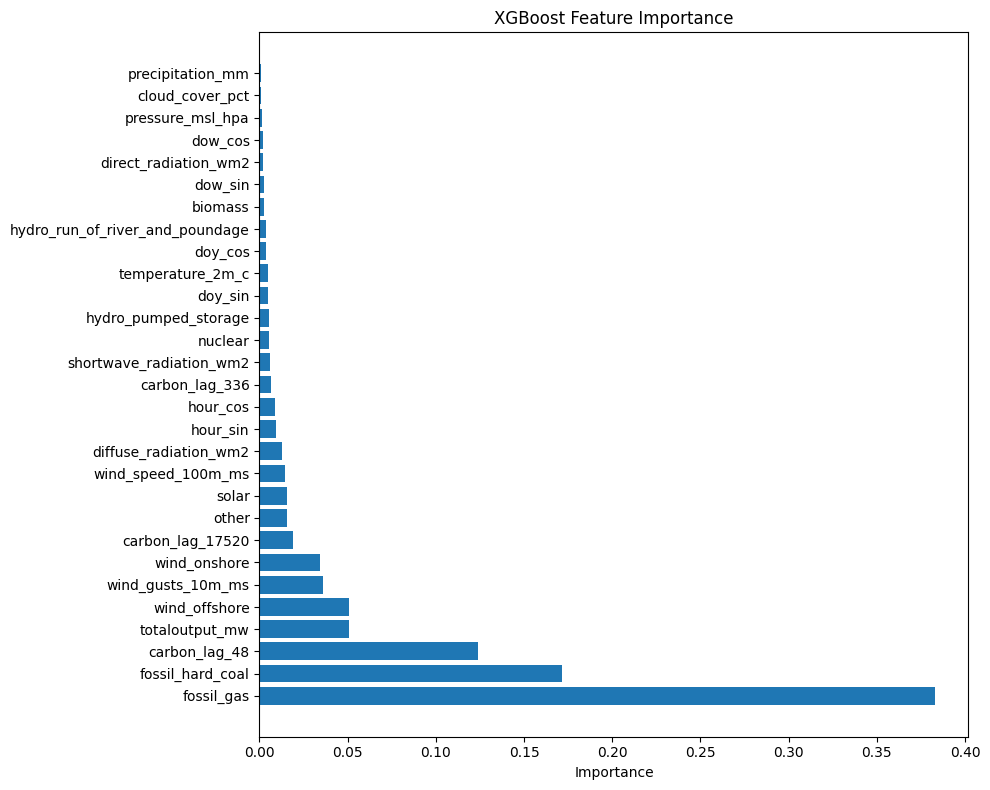

In [21]:
# get feature importance
importance = pd.DataFrame({
    "feature": model.get_booster().feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.to_string())

# plot
plt.figure(figsize=(10, 8))
plt.barh(importance["feature"], importance["importance"])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

                            feature  importance
10                       fossil_gas    0.382789
11                 fossil_hard_coal    0.171609
26                    carbon_lag_48    0.123998
19                   totaloutput_mw    0.050849
17                    wind_offshore    0.050604
2                 wind_gusts_10m_ms    0.036169
18                     wind_onshore    0.034558
28                 carbon_lag_17520    0.019162
15                            other    0.015794
16                            solar    0.015754
1                wind_speed_100m_ms    0.014382
6             diffuse_radiation_wm2    0.012820
20                         hour_sin    0.009530
21                         hour_cos    0.009077
27                   carbon_lag_336    0.006774
4           shortwave_radiation_wm2    0.005985
14                          nuclear    0.005633
12             hydro_pumped_storage    0.005382
24                          doy_sin    0.004917
0                  temperature_2m_c    0

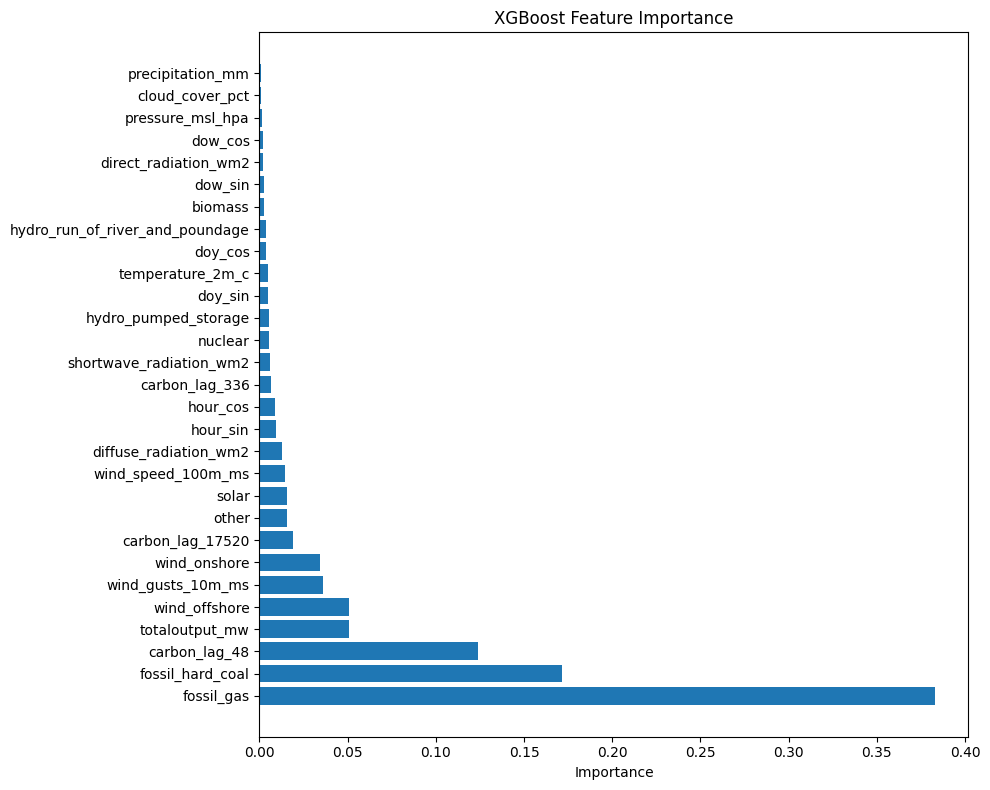

In [22]:
# get feature importance
importance = pd.DataFrame({
    "feature": model_fe.get_booster().feature_names,
    "importance": model_fe.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.to_string())

# plot
plt.figure(figsize=(10, 8))
plt.barh(importance["feature"], importance["importance"])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

Trying feature engineerign to iprove model

In [ ]:
param_grid = {
    'max_depth':        [6, 7, 8],
    'min_child_weight': [4, 6, 8],
    'subsample':        [0.8, 0.85, 0.9],
    'colsample_bytree': [0.75, 0.8, 0.85],
    'reg_lambda':       [1, 2, 3],
    'reg_alpha':        [0, 0.05, 0.1],
}

model_gs3 = XGBRegressor(
    random_state=42,
    n_estimators=3000,
    learning_rate=0.01,
    gamma=0,
    tree_method='hist',
    enable_categorical=False,
)

tscv = TimeSeriesSplit(n_splits=5)

grid_search3 = GridSearchCV(
    estimator=model_gs3,
    param_grid=param_grid,
    scoring=scorers,
    refit='RMSE',
    cv=tscv,
    verbose=2,
    n_jobs=-1,
)

grid_search3.fit(X_train, y_train)

print('Best params:', grid_search3.best_params_)

y_pred_gs3 = grid_search3.best_estimator_.predict(X_test)
y_pred_gs3_train = grid_search3.best_estimator_.predict(X_train)

print('\n--- Test Set ---')
print(f'MAE:       {mean_absolute_error(y_test, y_pred_gs3):.4f}')
print(f'MSE:       {mean_squared_error(y_test, y_pred_gs3):.4f}')
print(f'RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred_gs3)):.4f}')
print(f'R²:        {r2_score(y_test, y_pred_gs3):.4f}')
print(f'Max Error: {max_error(y_test, y_pred_gs3):.4f}')

print('\n--- Train Set ---')
print(f'MAE:       {mean_absolute_error(y_train, y_pred_gs3_train):.4f}')
print(f'MSE:       {mean_squared_error(y_